## Import packages

In [1]:
# If using Google Colab, uncomment the following line
# !pip install rasterio

import sys
print(sys.version)  # Print Python version in use

import numpy as np                                      # Array operations
import matplotlib.pyplot as plt                         # Plotting library
import torch                                            # Main PyTorch library
import torch.optim as optim                             # Optimization algorithms
import torch.nn as nn                                    # Neural network modules
import os                                               # Operating system utilities
import pandas as pd                                     # Data manipulation
import rasterio                                         # Geospatial raster data

from torch.utils.data import Dataset, DataLoader        # Dataset and batch data loading
from datetime import datetime                           # Date/time utilities
from rasterio.plot import show                           # Plot raster data

import deepSSF_model                                    # Import the .py file containing the deepSSF model     
import deepSSF_loss                                     # Import the .py file containing the deepSSF loss function
import deepSSF_early_stopping                           # Import the .py file containing the early stopping function   

# Get today's date
today_date = datetime.today().strftime('%Y-%m-%d')

# Set random seed for reproducibility
seed = 42

3.12.5 | packaged by Anaconda, Inc. | (main, Sep 12 2024, 18:18:29) [MSC v.1929 64 bit (AMD64)]


In [2]:
# import sys
# print(sys.version)

# import numpy as np
# import matplotlib.pyplot as plt
# import torch
# import torch.optim as optim
# from torch import nn
# from torch.utils.data import TensorDataset
# from torch.utils.data import Dataset
# from torch.utils.data import DataLoader
# from torchvision import datasets
# from torchvision.transforms import ToTensor
# from torchvision.transforms import v2

# import os
# import pandas as pd

# # from PIL import Image
# import rasterio

# Import the data and set up the dataset and dataloader

In [3]:
class buffalo_data(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.npy_base_path = ''

        # Ensure scalar columns are numeric and convert to tensors directly
        scalar_columns = [
            'hour_t1_sin1', 
            'hour_t1_cos1', 
            'yday_t1_sin1', 
            'yday_t1_cos1'
            ]
        
        self.data[scalar_columns] = self.data[scalar_columns].apply(pd.to_numeric, errors='coerce').fillna(0)
        self.scalar_to_grid_data = torch.from_numpy(self.data[scalar_columns].values).float()

        # Lag the values in column 'A' by one index to get the bearing of the previous step
        # Pad the missing value with a specified value, e.g., 0
        self.data['bearing_tm1'] = pd.to_numeric(self.data['bearing'], errors='coerce').shift(1).fillna(0)
        # Convert to tensor for training
        self.bearing_tm1 = torch.from_numpy(self.data[['bearing_tm1']].values).float()


    def __len__(self):
        return len(self.data)
    

    def __getitem__(self, index):
        # Load the input .npy files and stack them
        ndvi_path = os.path.join(self.npy_base_path, self.data.iloc[index]['ndvi_path'])
        canopy_path = os.path.join(self.npy_base_path, self.data.iloc[index]['canopy_path'])
        herby_path = os.path.join(self.npy_base_path, self.data.iloc[index]['herby_path'])
        slope_path = os.path.join(self.npy_base_path, self.data.iloc[index]['slope_path'])

        ndvi_npy = np.load(ndvi_path)
        ndvi_npy = np.nan_to_num(ndvi_npy, nan=-1.0) # Replace NaNs in the original array with -1, which represents water
        ndvi_tens = torch.tensor(ndvi_npy, dtype=torch.float32)
        canopy_tens = torch.tensor(np.load(canopy_path), dtype=torch.float32)
        herby_tens = torch.tensor(np.load(herby_path), dtype=torch.float32)
        slope_npy = np.load(slope_path)
        slope_npy = np.nan_to_num(slope_npy, nan=0.0) # Replace NaNs in the original array with 0
        slope_tens = torch.tensor(slope_npy, dtype=torch.float32) 

        spatial_data_x = torch.stack([ndvi_tens, canopy_tens, herby_tens, slope_tens], dim=0).squeeze()

        # Load the scalar values and bearing
        scalar_to_grid_data = self.scalar_to_grid_data[index]
        bearing_tm1 = self.bearing_tm1[index]

        # Load the target .tif file
        target_path = os.path.join(self.npy_base_path, self.data.iloc[index]['target_path'])
        # with rasterio.open(target_path) as src:
        #     target = torch.tensor(src.read(), dtype=torch.float32)
        target = torch.tensor(np.load(target_path), dtype=torch.float32)

        return spatial_data_x, scalar_to_grid_data, bearing_tm1, target


In [4]:
# Example usage
csv_file = 'C:/Users/for329/deepSSF_data/buffalo_all_steps_with_paths_n103558_steps.csv'
dataset = buffalo_data(csv_file)

training_split = 0.8
validation_split = 0.1
test_split = 0.1

dataset_train, dataset_val, dataset_test = torch.utils.data.random_split(dataset, [training_split, validation_split, test_split])
print(len(dataset_train))
print(len(dataset_val))
print(len(dataset_test))

82847
10356
10355


### Create dataloaders

In [5]:
os.cpu_count()

8

In [8]:
bs = 32 # batch size
num_workers = 0 # number of workers for data loader
dataloader_train = DataLoader(dataset=dataset_train, batch_size=bs, shuffle=True, num_workers=num_workers)
dataloader_val = DataLoader(dataset=dataset_val, batch_size=bs, shuffle=True, num_workers=num_workers)
dataloader_test = DataLoader(dataset=dataset_test, batch_size=bs, shuffle=True, num_workers=num_workers)

Feature x1 batch shape: torch.Size([32, 4, 101, 101])
Feature x2 batch shape: torch.Size([32, 4])
Feature x3 batch shape: torch.Size([32, 1])
Labels batch shape:     torch.Size([32, 101, 101])
tensor([ 0.3899, -0.9208,  0.8154,  0.5789])


Text(0.5, 1.0, 'Target location (next step)')

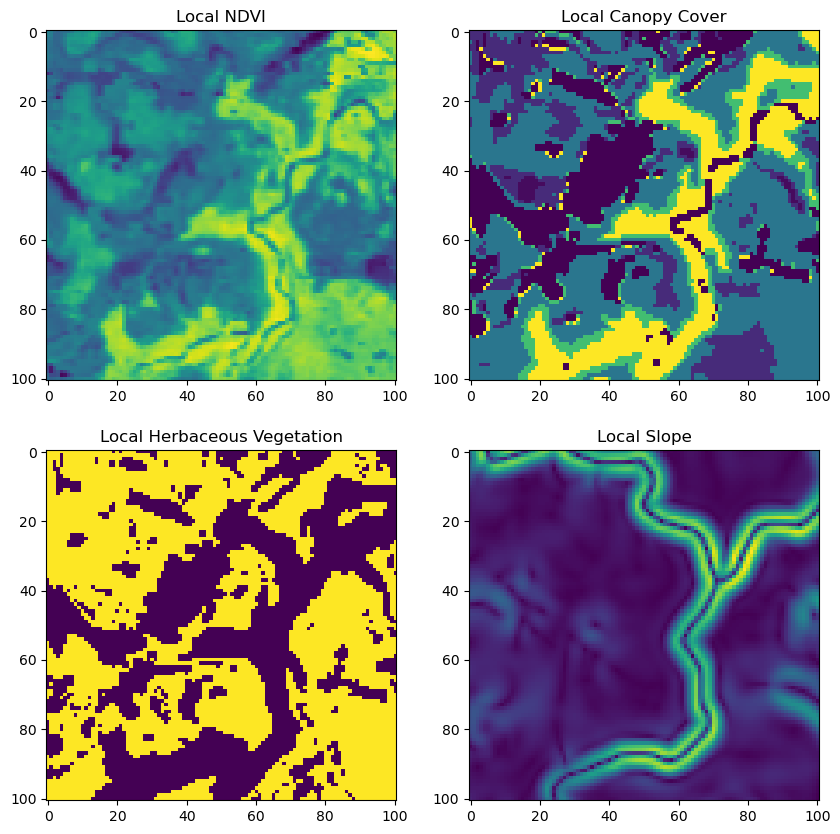

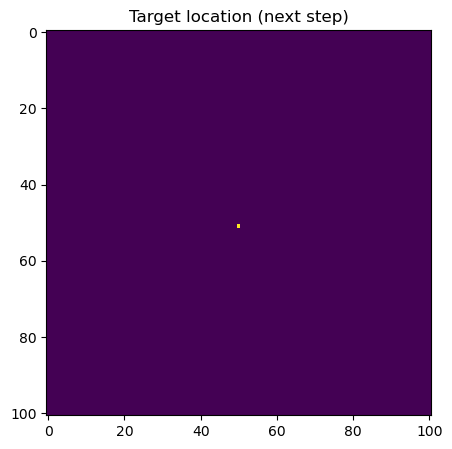

In [9]:
# Display image and label.
x1, x2, x3, labels = next(iter(dataloader_train))
print(f"Feature x1 batch shape: {x1.size()}")
print(f"Feature x2 batch shape: {x2.size()}")
print(f"Feature x3 batch shape: {x3.size()}")
print(f"Labels batch shape:     {labels.size()}")

# print(x3.detach().numpy())
print(x2[0,:])

# Plot the subset
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0, 0].imshow(x1.detach().numpy()[0,0,:,:], cmap='viridis')
axs[0, 0].set_title('Local NDVI')
axs[0, 1].imshow(x1.detach().numpy()[0,1,:,:], cmap='viridis')
axs[0, 1].set_title('Local Canopy Cover')
axs[1, 0].imshow(x1.detach().numpy()[0,2,:,:], cmap='viridis')
axs[1, 0].set_title('Local Herbaceous Vegetation')
axs[1, 1].imshow(x1.detach().numpy()[0,3,:,:], cmap='viridis')
axs[1, 1].set_title('Local Slope')

# Also plot the target as a single plot
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(labels.detach().numpy()[0,:,:], cmap='viridis')
ax.set_title('Target location (next step)')

# Load the model

As we have already described the model in detail in the `deepSSF_model` script, we can simply import the model here.

We will use the same model architecture as in the previous script, except that we will need to use a slightly edited dictionary to account for the additional input channels.

In [10]:
# run on the GPU or on the CPU, if a GPU is not available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using {device} device")

Using cpu device


## Define the parameters for the model

Here we enter the specific parameter values and hyperparameters for the model. 
These are the values that will be used to instantiate the model.

In [11]:
params_dict = {"batch_size": 32, #number of samples in each batch
               "image_dim": 101, #number of pixels along the edge of each local patch/image
               "pixel_size": 25, #number of metres along the edge of a pixel
               "dim_in_nonspatial_to_grid": 4, #the number of scalar predictors that are converted to a grid and appended to the spatial features
               "dense_dim_in_nonspatial": 4, #change this to however many other scalar predictors you have (bearing, velocity etc)
               "dense_dim_hidden": 128, #number of nodes in the hidden layers
               "dense_dim_out": 128, #number of nodes in the output of the fully connected block (FCN)
               "dense_dim_in_all": 2500,# + 128, #number of inputs entering the fully connected block once the nonspatial features have been concatenated to the spatial features
               "input_channels": 4 + 4, #number of spatial layers in each image + number of scalar layers that are converted to a grid
               "output_channels": 4, #number of filters to learn
               "kernel_size": 3, #the size of the 2D moving windows / kernels that are being learned
               "stride": 1, #the stride used when applying the kernel.  This reduces the dimension of the output if set to greater than 1
               "kernel_size_mp": 2, #the size of the kernel that is used in max pooling operations
               "stride_mp": 2, #the stride that is used in max pooling operations
               "padding": 1, #the amount of padding to apply to images prior to applying the 2D convolution
               "num_movement_params": 12, #number of parameters used to parameterise the movement kernel
               "dropout": 0.1, #the proportion of nodes that are dropped out in the dropout layers
               "device": device
               }

## Instantiate the model

As described in the `deepSSF_train.ipynb` script, we saved the model definition into a file named `deepSSF_model.py`. We can instantiate the model by importing the file (which was done when importing other packages) and calling the classes parameter dictionary from that script.

In [12]:
params = deepSSF_model.ModelParams(params_dict)
model = deepSSF_model.ConvJointModel(params).to(device)
print(model)

ConvJointModel(
  (scalar_grid_output): Scalar_to_Grid_Block()
  (conv_habitat): Conv2d_block_spatial(
    (conv2d): Sequential(
      (0): Conv2d(8, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(4, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
  )
  (conv_movement): Conv2d_block_toFC(
    (conv2d): Sequential(
      (0): Conv2d(8, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Flatten(start_dim=1, end_dim=-1)
    )
  )
  (fcn_movement_all): FCN_block_all_movement(
    (ffn): Sequential(
      (0): Linear(in_features=2500, out_features=128, b

## Set model hyperparameters

Set the learning rate, loss function, optimizer, scheduler and early stopping. 

In [13]:
learning_rate = 1e-3

# Define the negative log-likelihood loss function with mean reduction
loss_fn = deepSSF_loss.negativeLogLikeLoss(reduction='mean')

# path to save the model weights
path_save_weights = f'model_checkpoints/deepSSF_derived-covs_single_input_buffalo_{today_date}.pt'

# Set up the Adam optimizer for updating the model's parameters
optimiser = optim.Adam(model.parameters(), lr=learning_rate)

# Create a learning rate scheduler that reduces the LR by a factor of 0.1 
#    if validation loss has not improved for 'patience=5' epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser,  # The optimizer whose learning rate will be adjusted
    mode='min', # The metric to be minimized (e.g., validation loss)
    factor=0.1, # Factor by which the learning rate will be reduced
    patience=5  # Number of epochs with no improvement before learning rate reduces
)

# EarlyStopping stops training after 'patience=10' epochs with no improvement, 
#    optionally saving the best model weights
early_stopping = deepSSF_early_stopping.EarlyStopping(patience=20, verbose=True, path=path_save_weights)

## Training loop

This code defines the main training loop for a single epoch. It iterates over batches from the training dataloader, moves the data to the correct device (e.g., CPU or GPU), calculates the loss, and performs backpropagation to update the model parameters. It also prints periodic updates of the current loss.

In [14]:
def train_loop(dataloader_train, model, loss_fn, optimiser):
    """
    Runs the training process for one epoch using the given dataloader, model, 
    loss function, and optimizer. Prints progress updates every few batches.
    """

    # 1. Total number of training examples
    size = len(dataloader_train.dataset)

    # 2. Put model in training mode (affects layers like dropout, batchnorm)
    model.train()

    # 3. Variable to accumulate the total loss over the epoch
    epoch_loss = 0.0

    # 4. Loop over batches in the training dataloader
    for batch, (x1, x2, x3, y) in enumerate(dataloader_train):

        # Move the batch of data to the specified device (CPU/GPU)
        x1 = x1.to(device)
        x2 = x2.to(device)
        x3 = x3.to(device)
        y = y.to(device)

        # Forward pass: compute the model output and loss
        loss = loss_fn(model((x1, x2, x3)), y)
        epoch_loss += loss

        # Backpropagation: compute gradients and update parameters
        loss.backward()
        optimiser.step()

        # Reset gradients before the next iteration
        optimiser.zero_grad()

        # Print an update every 5 batches to keep track of training progress
        if batch % 5 == 0:
            loss_val = loss.item()
            current = batch * bs + len(x1)
            print(f"loss: {loss_val:>15f}  [{current:>5d}/{size:>5d}]")

## Test loop

The test loop is similar to the training loop, but it does not perform backpropagation. It calculates the loss on the test set and returns the average loss.

In [15]:
def test_loop(dataloader_test, model, loss_fn):
    """
    Evaluates the model on the provided test dataset by computing 
    the average loss over all batches. 
    No gradients are computed during this process (torch.no_grad()).
    """

    # 1. Set the model to evaluation mode (affects layers like dropout, batchnorm).
    model.eval()

    size = len(dataloader_test.dataset)
    num_batches = len(dataloader_test)
    
    test_loss = 0

    # 2. Disable gradient computation to speed up evaluation and reduce memory usage
    with torch.no_grad():
        # 3. Loop through each batch in the test dataloader
        for x1, x2, x3, y in dataloader_test:

            # Move the batch of data to the appropriate device (CPU/GPU)
            x1 = x1.to(device)
            x2 = x2.to(device)
            x3 = x3.to(device)
            y = y.to(device)

            # Compute the loss on the test set (no backward pass needed)
            test_loss += loss_fn(model((x1, x2, x3)), y)

    # 4. Compute average test loss over all batches
    test_loss /= num_batches

    # Print the average test loss
    print(f"Avg test loss: {test_loss:>15f} \n")

## Train the model

In [16]:
epochs = 100
val_losses = []   # Track validation losses across epochs

for t in range(epochs):
    val_loss = 0.0
    num_batches = len(dataloader_test)

    print(f"Epoch {t+1}\n-------------------------------")

    # 1. Run the training loop for one epoch using the training dataloader
    train_loop(dataloader_train, model, loss_fn, optimiser)

    # 2. Evaluate model performance on the validation dataset
    model.eval()  # Switch to evaluation mode for proper layer behavior
    with torch.no_grad():
        
        for x1, x2, x3, y in dataloader_val:
            # Move data to the chosen device (CPU/GPU)
            x1 = x1.to(device)
            x2 = x2.to(device)
            x3 = x3.to(device)
            y = y.to(device)

            # Accumulate validation loss
            val_loss += loss_fn(model((x1, x2, x3)), y)

    # 3. Step the scheduler based on the validation loss (adjusts learning rate if needed)
    scheduler.step(val_loss)

    # 4. Compute the average validation loss and print it, along with the current learning rate
    val_loss /= num_batches
    print(f"\nAvg validation loss: {val_loss:>15f}")
    print(f"Learning rate: {scheduler.get_last_lr()}")

    # 5. Track the validation loss for plotting or monitoring
    val_losses.append(val_loss)

    # 6. Early stopping: if no improvement in validation loss for a set patience, stop training
    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Early stopping")
        # Restore the best model weights saved by EarlyStopping
        model.load_state_dict(torch.load(path_save_weights, weights_only=True))
        test_loop(dataloader_test, model, loss_fn)  # Evaluate on test set once training stops
        break
    else:
        model.eval()
        print("\n")

print("Done!")

Epoch 1
-------------------------------
loss:        0.000802  [   32/82847]
loss:        0.000622  [  192/82847]
loss:        0.000651  [  352/82847]
loss:        0.000641  [  512/82847]
loss:        0.000604  [  672/82847]
loss:        0.000602  [  832/82847]
loss:        0.000538  [  992/82847]
loss:        0.000593  [ 1152/82847]
loss:        0.000604  [ 1312/82847]
loss:        0.000575  [ 1472/82847]
loss:        0.000577  [ 1632/82847]
loss:        0.000540  [ 1792/82847]
loss:        0.000702  [ 1952/82847]
loss:        0.000544  [ 2112/82847]
loss:        0.000592  [ 2272/82847]


KeyboardInterrupt: 